<a href="https://colab.research.google.com/github/VasilinaFrolova/-/blob/main/%D0%A0%D0%B0%D1%81%D1%87%D0%B5%D1%82_%D0%BF%D0%BE_%D0%A1%D0%BF%D0%B8%D1%80%D0%BC%D0%B5%D0%BD%D1%83_%D1%82%D0%BE%D0%BB%D1%8C%D0%BA%D0%BE_%D1%81%D1%83%D0%B1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Загрузка файла в Google Colab
from google.colab import files
import pandas as pd
from scipy.stats import spearmanr

In [ ]:
# 1. Загрузите ваш Excel-файл
uploaded = files.upload()  # откроется диалог выбора файла

Saving Спирмен_субъективный только.xlsx to Спирмен_субъективный только.xlsx


In [ ]:
# Получим имя загруженного файла
file_name = next(iter(uploaded))
print(f"Загружен файл: {file_name}")

Загружен файл: Спирмен_субъективный только.xlsx


In [ ]:
# 2. Читаем все листы
xls = pd.ExcelFile(file_name)
sheet_names = xls.sheet_names
print("Доступные листы:", sheet_names)

Доступные листы: ['суб.убедительность и приобрет.', 'суб.запоминаемость и приобрет.', 'суб.внимание и приобрет.', 'суб. сильная эмоц. и приобрет.', 'суб. убедит. и запоминаемость']


In [ ]:
# Функция для расчёта Спирмена по парам столбцов
def compute_spearman_for_banners(df, metric1_suffix, metric2_suffix, group_col=None):
    """
    Вычисляет корреляцию Спирмена между метриками metric1_suffix и metric2_suffix
    для каждой рекламы (1-10). Можно передать имя столбца для группировки (пол/возраст).
    Возвращает список словарей с результатами.
    """
    results = []
    for i in range(1, 11):
        col1 = f"Б{i}_{metric1_suffix}"
        col2 = f"Б{i}_{metric2_suffix}"
        if group_col:
            grouped = df.groupby(group_col)
            for group_name, group_df in grouped:
                valid = group_df[[col1, col2]].dropna()
                if len(valid) < 3:
                    continue
                rho, p = spearmanr(valid[col1], valid[col2])
                results.append({
                    "Группа": group_name,
                    "Реклама": i,
                    "Метрика 1": col1,
                    "Метрика 2": col2,
                    "Спирмен ρ": round(rho, 4),
                    "p-значение": round(p, 4)
                })
        else:
            valid = df[[col1, col2]].dropna()
            if len(valid) < 3:
                continue
            rho, p = spearmanr(valid[col1], valid[col2])
            results.append({
                "Реклама": i,
                "Метрика 1": col1,
                "Метрика 2": col2,
                "Спирмен ρ": round(rho, 4),
                "p-значение": round(p, 4)
            })
    return results

In [ ]:
# 4. Автоматический перебор всех листов и сбор результатов
all_results = []   # список для накопления DataFrame с результатами

for sheet in sheet_names:
    df = pd.read_excel(file_name, sheet_name=sheet)

    # Определяем метрики по названию листа
    if "убедительность" in sheet and "приобрет" in sheet:
        m1, m2 = "Убедительность", "Приобретение"
    elif "запоминаемость" in sheet and "приобрет" in sheet:
        m1, m2 = "Запоминаемость", "Приобретение"
    elif "внимание" in sheet and "приобрет" in sheet:
        m1, m2 = "Внимание", "Приобретение"
    elif "эмоц" in sheet and "приобрет" in sheet:
        m1, m2 = "Эмоция", "Приобретение"
    elif "убедит" in sheet and "запоминаемость" in sheet:
        m1, m2 = "Убедительность", "Запоминаемость"
    else:
        print(f"Пропускаем лист '{sheet}' — неизвестная структура имени")
        continue

    print(f"\n========== Лист: {sheet} ==========")

    # Общая корреляция
    res_all = compute_spearman_for_banners(df, m1, m2)
    df_all = pd.DataFrame(res_all)
    print("Общая корреляция:")
    print(df_all.to_string(index=False))
    df_all['Лист'] = sheet
    df_all['Тип анализа'] = 'Общий'
    all_results.append(df_all)

    # По полу
    res_gender = compute_spearman_for_banners(df, m1, m2, group_col="Ваш пол")
    df_gender = pd.DataFrame(res_gender)
    print("\nПо полу:")
    print(df_gender.to_string(index=False))
    df_gender['Лист'] = sheet
    df_gender['Тип анализа'] = 'По полу'
    all_results.append(df_gender)

    # По возрасту
    res_age = compute_spearman_for_banners(df, m1, m2, group_col="Ваш возраст")
    df_age = pd.DataFrame(res_age)
    print("\nПо возрасту:")
    print(df_age.to_string(index=False))
    df_age['Лист'] = sheet
    df_age['Тип анализа'] = 'По возрасту'
    all_results.append(df_age)


========== Лист: суб.убедительность и приобрет. ==========
Общая корреляция:
 Реклама          Метрика 1        Метрика 2  Спирмен ρ  p-значение
       1  Б1_Убедительность  Б1_Приобретение     0.6520         0.0
       2  Б2_Убедительность  Б2_Приобретение     0.5793         0.0
       3  Б3_Убедительность  Б3_Приобретение     0.6076         0.0
       4  Б4_Убедительность  Б4_Приобретение     0.7090         0.0
       5  Б5_Убедительность  Б5_Приобретение     0.7247         0.0
       6  Б6_Убедительность  Б6_Приобретение     0.6931         0.0
       7  Б7_Убедительность  Б7_Приобретение     0.6490         0.0
       8  Б8_Убедительность  Б8_Приобретение     0.6913         0.0
       9  Б9_Убедительность  Б9_Приобретение     0.7252         0.0
      10 Б10_Убедительность Б10_Приобретение     0.7151         0.0

По полу:
 Группа  Реклама          Метрика 1        Метрика 2  Спирмен ρ  p-значение
Женский        1  Б1_Убедительность  Б1_Приобретение     0.6366      0.0000
Мужской     

/tmp/ipykernel_7562/2552426310.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(valid[col1], valid[col2])



По возрасту:
Группа  Реклама          Метрика 1        Метрика 2  Спирмен ρ  p-значение
 18–24        1  Б1_Убедительность  Б1_Приобретение     0.6838      0.0000
 25–34        1  Б1_Убедительность  Б1_Приобретение     0.5512      0.0788
 35–44        1  Б1_Убедительность  Б1_Приобретение     0.6227      0.0132
 45–54        1  Б1_Убедительность  Б1_Приобретение     0.7246      0.0001
 55–64        1  Б1_Убедительность  Б1_Приобретение     0.4536      0.3066
   65+        1  Б1_Убедительность  Б1_Приобретение     1.0000      0.0000
 18–24        2  Б2_Убедительность  Б2_Приобретение     0.5143      0.0003
 25–34        2  Б2_Убедительность  Б2_Приобретение     0.3592      0.2779
 35–44        2  Б2_Убедительность  Б2_Приобретение     0.8615      0.0000
 45–54        2  Б2_Убедительность  Б2_Приобретение     0.6996      0.0003
 55–64        2  Б2_Убедительность  Б2_Приобретение     0.2733      0.5532
   65+        2  Б2_Убедительность  Б2_Приобретение     0.3333      0.6667
 18–24     

/tmp/ipykernel_7562/2552426310.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(valid[col1], valid[col2])
/tmp/ipykernel_7562/2552426310.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(valid[col1], valid[col2])



По возрасту:
Группа  Реклама          Метрика 1        Метрика 2  Спирмен ρ  p-значение
 18–24        1  Б1_Запоминаемость  Б1_Приобретение     0.5294      0.0002
 25–34        1  Б1_Запоминаемость  Б1_Приобретение     0.5369      0.0886
 35–44        1  Б1_Запоминаемость  Б1_Приобретение     0.7499      0.0013
 45–54        1  Б1_Запоминаемость  Б1_Приобретение     0.4510      0.0352
 55–64        1  Б1_Запоминаемость  Б1_Приобретение     0.2495      0.5895
   65+        1  Б1_Запоминаемость  Б1_Приобретение    -0.5774      0.4226
 18–24        2  Б2_Запоминаемость  Б2_Приобретение     0.4626      0.0014
 25–34        2  Б2_Запоминаемость  Б2_Приобретение     0.3301      0.3216
 35–44        2  Б2_Запоминаемость  Б2_Приобретение     0.7871      0.0005
 45–54        2  Б2_Запоминаемость  Б2_Приобретение     0.5313      0.0109
 55–64        2  Б2_Запоминаемость  Б2_Приобретение    -0.1034      0.8255
   65+        2  Б2_Запоминаемость  Б2_Приобретение    -0.5774      0.4226
 18–24     

/tmp/ipykernel_7562/2552426310.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(valid[col1], valid[col2])
/tmp/ipykernel_7562/2552426310.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(valid[col1], valid[col2])



По возрасту:
Группа  Реклама    Метрика 1        Метрика 2  Спирмен ρ  p-значение
 18–24        1  Б1_Внимание  Б1_Приобретение     0.5652      0.0001
 25–34        1  Б1_Внимание  Б1_Приобретение     0.4579      0.1567
 35–44        1  Б1_Внимание  Б1_Приобретение     0.7532      0.0012
 45–54        1  Б1_Внимание  Б1_Приобретение     0.7370      0.0001
 55–64        1  Б1_Внимание  Б1_Приобретение     0.5134      0.2386
   65+        1  Б1_Внимание  Б1_Приобретение        NaN         NaN
 18–24        2  Б2_Внимание  Б2_Приобретение     0.4612      0.0014
 25–34        2  Б2_Внимание  Б2_Приобретение     0.3980      0.2253
 35–44        2  Б2_Внимание  Б2_Приобретение     0.6861      0.0047
 45–54        2  Б2_Внимание  Б2_Приобретение     0.5661      0.0060
 55–64        2  Б2_Внимание  Б2_Приобретение    -0.2333      0.6146
   65+        2  Б2_Внимание  Б2_Приобретение     1.0000      0.0000
 18–24        3  Б3_Внимание  Б3_Приобретение     0.6829      0.0000
 25–34        3  Б3_

/tmp/ipykernel_7562/2552426310.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(valid[col1], valid[col2])



По возрасту:
Группа  Реклама  Метрика 1        Метрика 2  Спирмен ρ  p-значение
 18–24        1  Б1_Эмоция  Б1_Приобретение     0.6561      0.0000
 25–34        1  Б1_Эмоция  Б1_Приобретение     0.8255      0.0018
 35–44        1  Б1_Эмоция  Б1_Приобретение     0.6037      0.0172
 45–54        1  Б1_Эмоция  Б1_Приобретение     0.5973      0.0033
 55–64        1  Б1_Эмоция  Б1_Приобретение     0.1491      0.7497
   65+        1  Б1_Эмоция  Б1_Приобретение        NaN         NaN
 18–24        2  Б2_Эмоция  Б2_Приобретение     0.4327      0.0030
 25–34        2  Б2_Эмоция  Б2_Приобретение     0.6156      0.0437
 35–44        2  Б2_Эмоция  Б2_Приобретение     0.5828      0.0226
 45–54        2  Б2_Эмоция  Б2_Приобретение     0.7330      0.0001
 55–64        2  Б2_Эмоция  Б2_Приобретение     0.8269      0.0218
   65+        2  Б2_Эмоция  Б2_Приобретение    -1.0000      0.0000
 18–24        3  Б3_Эмоция  Б3_Приобретение     0.6282      0.0000
 25–34        3  Б3_Эмоция  Б3_Приобретение     

In [ ]:
# Отбираем только "Общий" анализ по всем листам (без разделения по полу/возрасту)
df_all = pd.concat(all_results, ignore_index=True)
general = df_all[df_all['Тип анализа'] == 'Общий'].copy()

# Создаём колонку с коротким названием пары метрик (например, "Убедительность → Приобретение")
# Можно оставить 'Лист' как есть, но лучше сделать нагляднее
general['Пара_метрик'] = general['Лист'].apply(
    lambda x: x.replace('суб.', '').replace(' и ', ' vs ').strip()
)

# Сводная таблица: строки – баннеры (1..10), столбцы – пары метрик
heatmap_data = general.pivot_table(
    index='Реклама',
    columns='Пара_метрик',
    values='Спирмен ρ',
    aggfunc='mean'  # на случай, если есть дубли (их быть не должно)
)

# Упорядочим колонки для удобства (по желанию)
column_order = [
    'убедительность vs приобрет.',
    'запоминаемость vs приобрет.',
    'внимание vs приобрет.',
    ' сильная эмоц. vs приобрет.',
    ' убедит. vs запоминаемость'
]
existing_cols = [col for col in column_order if col in heatmap_data.columns]
heatmap_data = heatmap_data[existing_cols]

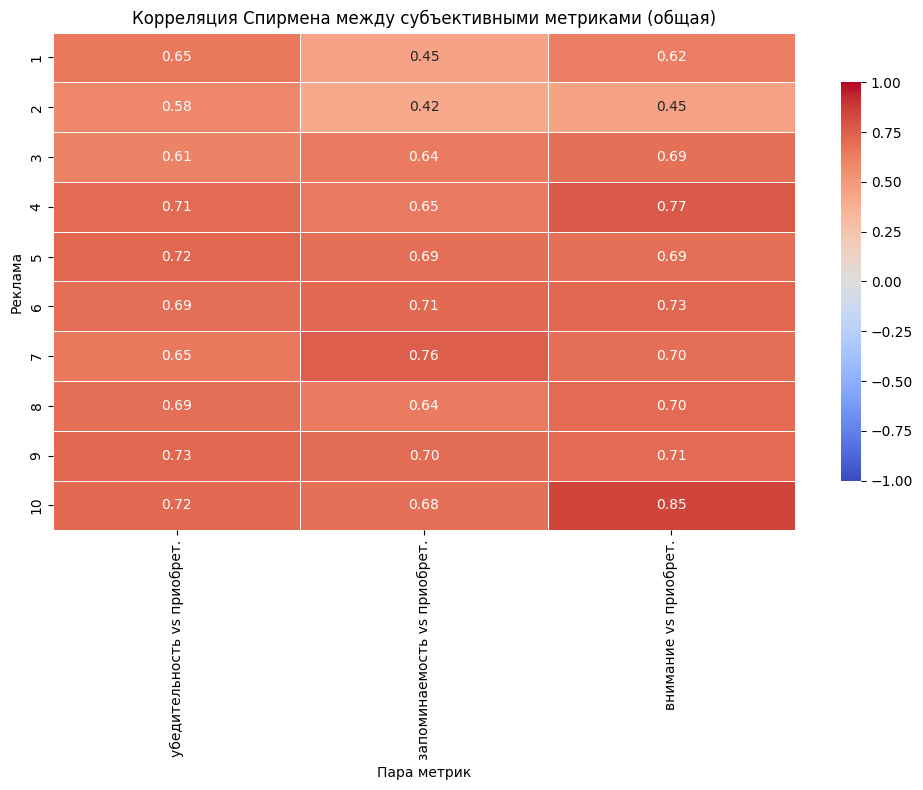

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    vmin=-1, vmax=1,
    cbar_kws={'shrink': 0.8}
)
plt.title('Корреляция Спирмена между субъективными метриками (общая)')
plt.ylabel('Реклама')
plt.xlabel('Пара метрик')
plt.tight_layout()

# Сохранение
plt.savefig('heatmap_субъективные_пары.png', dpi=300, bbox_inches='tight')
plt.show()

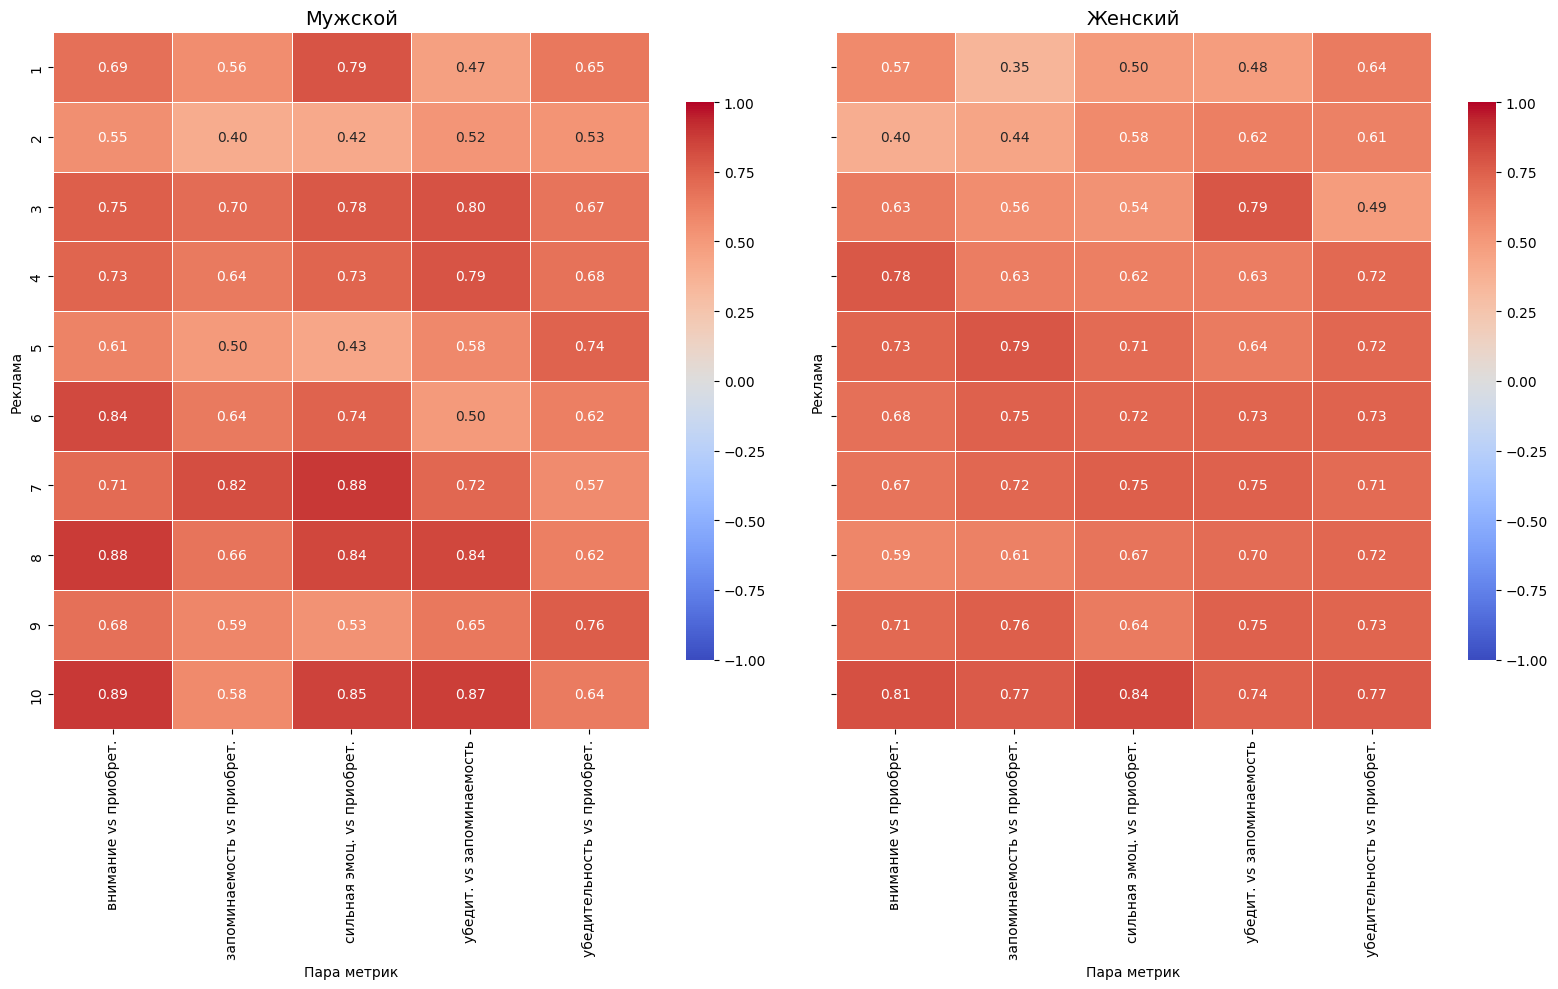

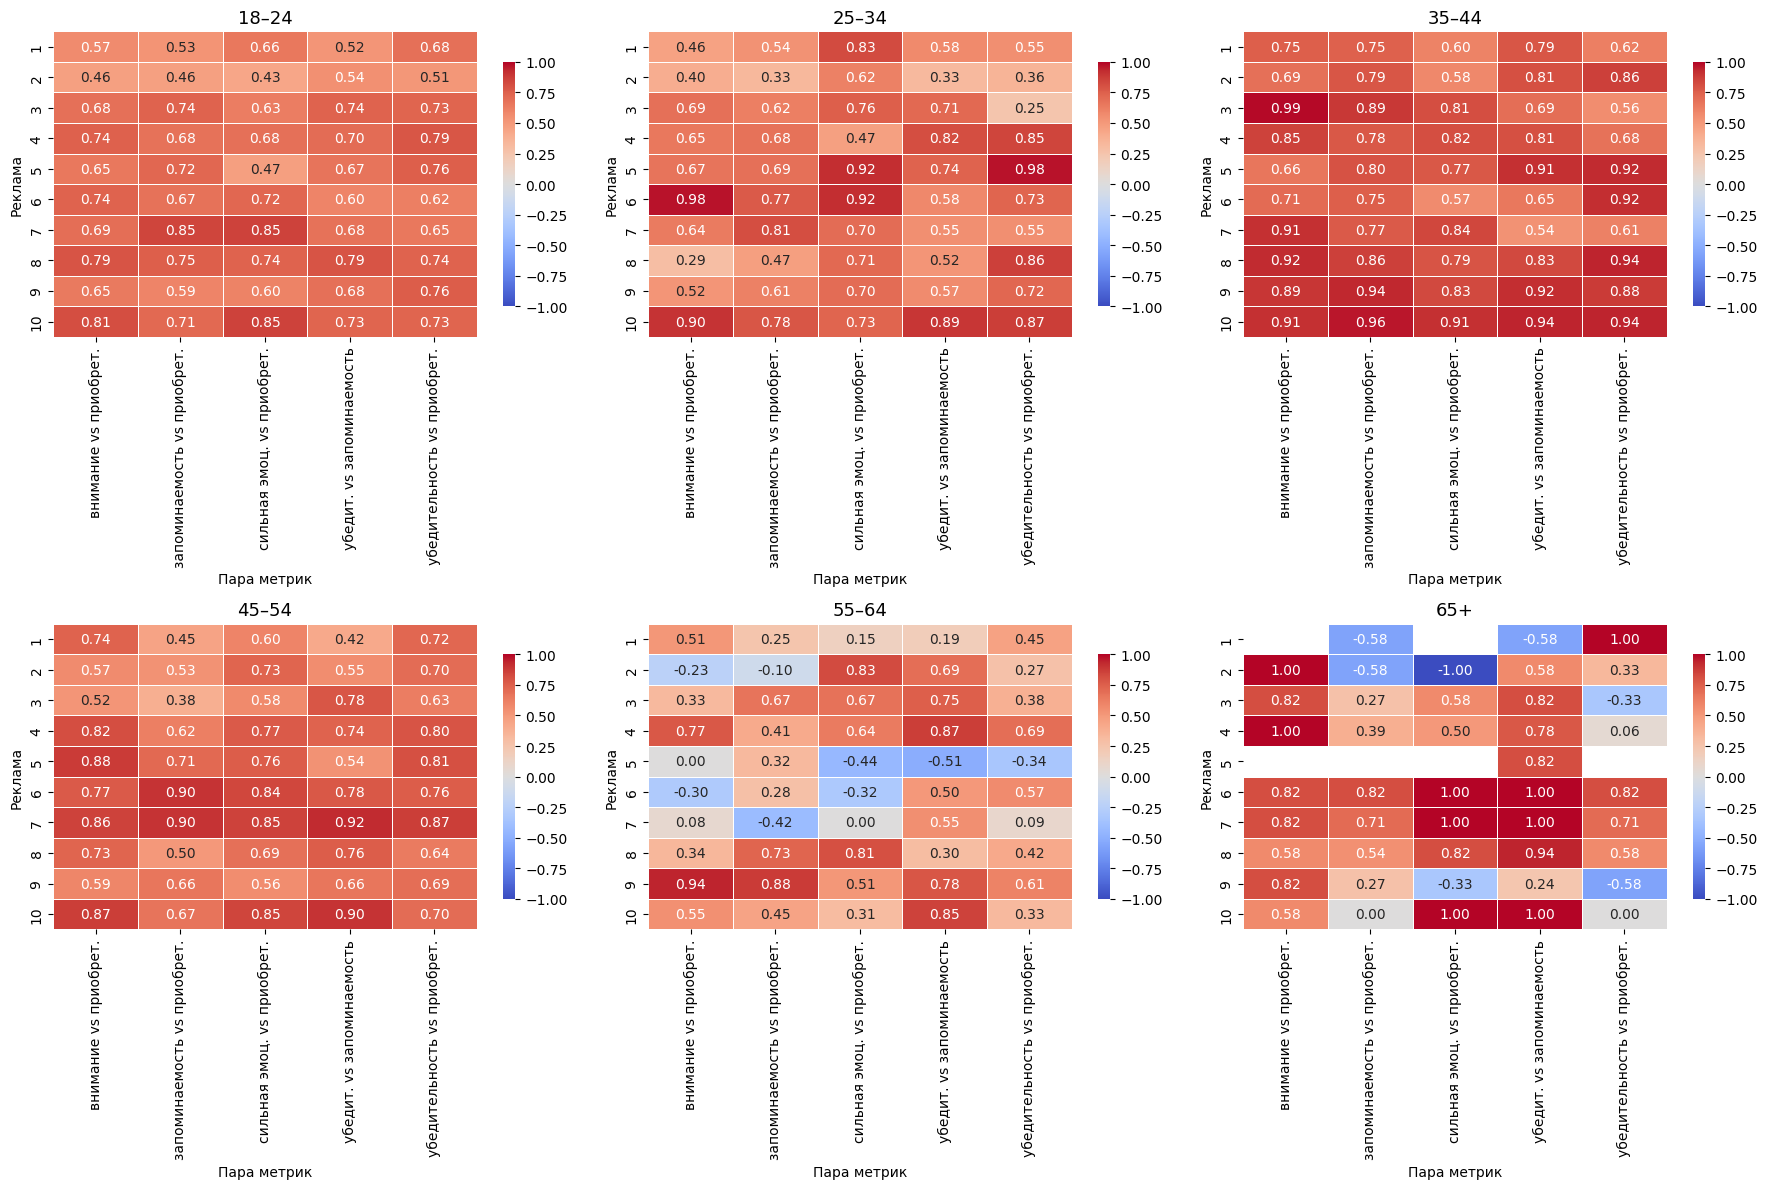

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Подготовка данных: отбираем нужные срезы
df_all = pd.concat(all_results, ignore_index=True)

# --- 1. Тепловые карты по полу (Мужчины / Женщины) ---
gender_data = df_all[df_all['Тип анализа'] == 'По полу'].copy()
# Создаём читаемое название пары метрик
gender_data['Пара_метрик'] = gender_data['Лист'].apply(
    lambda x: x.replace('суб.', '').replace(' и ', ' vs ').strip()
)

# Разделяем по группам
genders = ['Мужской', 'Женский']
fig, axes = plt.subplots(1, 2, figsize=(16, 10), sharey=True)

for ax, gender in zip(axes, genders):
    subset = gender_data[gender_data['Группа'] == gender]
    pivot = subset.pivot_table(index='Реклама', columns='Пара_метрик', values='Спирмен ρ')
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                vmin=-1, vmax=1, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
    ax.set_title(f'{gender}', fontsize=14)
    ax.set_ylabel('Реклама')
    ax.set_xlabel('Пара метрик')
plt.tight_layout()
plt.savefig('heatmap_по_полу.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 2. Тепловые карты по возрасту ---
age_data = df_all[df_all['Тип анализа'] == 'По возрасту'].copy()
age_data['Пара_метрик'] = age_data['Лист'].apply(
    lambda x: x.replace('суб.', '').replace(' и ', ' vs ').strip()
)

# Возрастные группы (упорядочим)
age_order = ['18–24', '25–34', '35–44', '45–54', '55–64', '65+']
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()  # превращаем в одномерный массив для удобства

for ax, age_gr in zip(axes, age_order):
    subset = age_data[age_data['Группа'] == age_gr]
    if subset.empty:
        ax.axis('off')
        continue
    pivot = subset.pivot_table(index='Реклама', columns='Пара_метрик', values='Спирмен ρ')
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                vmin=-1, vmax=1, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
    ax.set_title(age_gr, fontsize=13)
    ax.set_ylabel('Реклама')
    ax.set_xlabel('Пара метрик')

# Отключаем лишние оси, если групп меньше 6 (на всякий случай скрываем пустые)
for i in range(len(age_order), len(axes)):
    axes[i].axis('off')
plt.tight_layout()
plt.savefig('heatmap_по_возрасту.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# 5. Сохранение всех результатов в один файл
if all_results:
    final_df = pd.concat(all_results, ignore_index=True)
    final_df.to_excel('spearman_results_all.xlsx', index=False)
    final_df.to_csv('spearman_results_all.csv', index=False)
    print("\n✅ Все результаты сохранены в файлы: 'spearman_results_all.xlsx' и 'spearman_results_all.csv'")
else:
    print("\n❌ Нет данных для сохранения.")


✅ Все результаты сохранены в файлы: 'spearman_results_all.xlsx' и 'spearman_results_all.csv'
